<a href="https://colab.research.google.com/github/priyanshiii7/DASGRI-2026/blob/main/Multi_Disease_XAI_DASGRI2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports


In [26]:
# Install all required libraries
!pip install shap lime xgboost scikit-learn pandas numpy matplotlib seaborn -q

print(" All libraries installed!")

 All libraries installed!


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve, precision_score,
                             recall_score, f1_score)

# XGBoost
import xgboost as xgb

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# XAI
import shap
import lime
import lime.lime_tabular
import time

print("All imports successful!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

All imports successful!
PyTorch version: 2.9.0+cpu
CUDA available: False


# Uploading datasets

In [28]:
# Upload heart disease and diabetes CSV files
from google.colab import files

print(" Upload Heart Disease CSV file:")
uploaded = files.upload()
heart_disease_file = list(uploaded.keys())[0]

print("\n Upload Diabetes CSV file:")
uploaded = files.upload()
diabetes_file = list(uploaded.keys())[0]

print(f"\n Files uploaded:")
print(f"   - Heart Disease: {heart_disease_file}")
print(f"   - Diabetes: {diabetes_file}")

 Upload Heart Disease CSV file:


Saving heart.csv to heart (2).csv

 Upload Diabetes CSV file:


Saving diabetes.csv to diabetes (2).csv

 Files uploaded:
   - Heart Disease: heart (2).csv
   - Diabetes: diabetes (2).csv


# Load Datasets

In [34]:
# Function to load and prepare datasets
def load_dataset(dataset_name):
    """Load dataset and return X, y, feature_names"""

    if dataset_name == 'breast_cancer':
        data = load_breast_cancer()
        X = pd.DataFrame(data.data, columns=data.feature_names)
        y = pd.Series(data.target, name='target')
        return X, y, data.feature_names, ['malignant', 'benign']

    elif dataset_name == 'heart_disease':
        # Load heart disease CSV
        df = pd.read_csv(heart_disease_file)

        # Assuming last column is target (adjust if different)
        X = df.iloc[:, :-1]
        y = df.iloc[:, -1]

        return X, y, X.columns.tolist(), ['no disease', 'disease']

    elif dataset_name == 'diabetes':
        # Load diabetes CSV
        df = pd.read_csv(diabetes_file)

        # Assuming 'Outcome' is target column (adjust if different)
        if 'Outcome' in df.columns:
            X = df.drop('Outcome', axis=1)
            y = df['Outcome']
        else:
            X = df.iloc[:, :-1]
            y = df.iloc[:, -1]

        return X, y, X.columns.tolist(), ['no diabetes', 'diabetes']

# Load all datasets
print(" Loading datasets...\n")

datasets = {}
for name in ['breast_cancer', 'heart_disease', 'diabetes']:
    X, y, features, classes = load_dataset(name)
    datasets[name] = {
        'X': X,
        'y': y,
        'feature_names': features,
        'class_names': classes
    }
    print(f" {name.replace('_', ' ').title()}:")
    print(f"   Samples: {len(X)}")
    print(f"   Features: {len(features)}")
    print(f"   Classes: {classes}")
    print(f"   Class distribution: {y.value_counts().to_dict()}\n")

print("All datasets loaded successfully!")

 Loading datasets...

 Breast Cancer:
   Samples: 569
   Features: 30
   Classes: ['malignant', 'benign']
   Class distribution: {1: 357, 0: 212}

 Heart Disease:
   Samples: 1025
   Features: 13
   Classes: ['no disease', 'disease']
   Class distribution: {1: 526, 0: 499}

 Diabetes:
   Samples: 768
   Features: 8
   Classes: ['no diabetes', 'diabetes']
   Class distribution: {0: 500, 1: 268}

All datasets loaded successfully!


# Master training function

In [30]:
print(" Starting fresh training pipeline...")

# ===== MASTER TRAINING FUNCTION =====
def train_and_evaluate_all_models(dataset_name, X, y, feature_names, class_names):
    """
    Train all models and apply all XAI methods
    Returns complete results dictionary
    """

    print(f"\n{'='*60}")
    print(f" Processing: {dataset_name.replace('_', ' ').upper()}")
    print(f"{'='*60}\n")

    results = {
        'dataset': dataset_name,
        'models': {},
        'xai': {},
        'figures': []
    }

    # ===== STEP 1: Split and Normalize =====
    print(" Step 1: Preprocessing...")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    print(f"   Train: {len(X_train)} | Test: {len(X_test)}")

    # ===== STEP 2: Train Models =====
    print("\n Step 2: Training models...")

    # Random Forest
    print("   Training Random Forest...")
    rf_model = RandomForestClassifier(n_estimators=100, max_depth=10,
                                     random_state=42, n_jobs=-1)
    rf_model.fit(X_train_scaled, y_train)

    # XGBoost
    print("   Training XGBoost...")
    xgb_model = xgb.XGBClassifier(n_estimators=100, max_depth=6,
                                  learning_rate=0.1, random_state=42,
                                  use_label_encoder=False, eval_metric='logloss')
    xgb_model.fit(X_train_scaled, y_train)

    # Neural Network - Create inline to avoid namespace issues
    print("   Training Neural Network...")
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Convert to numpy arrays properly
    if hasattr(y_train, 'values'):
        y_train_np = y_train.values
        y_test_np = y_test.values
    elif isinstance(y_train, pd.Series):
        y_train_np = y_train.to_numpy()
        y_test_np = y_test.to_numpy()
    else:
        y_train_np = np.array(y_train)
        y_test_np = np.array(y_test)

    # Prepare PyTorch tensors
    X_train_tensor = torch.FloatTensor(X_train_scaled).to(device)
    y_train_tensor = torch.LongTensor(y_train_np).to(device)
    X_test_tensor = torch.FloatTensor(X_test_scaled).to(device)
    y_test_tensor = torch.LongTensor(y_test_np).to(device)

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

    # Create Sequential model directly (no class needed!)
    input_size = X_train.shape[1]
    nn_model = torch.nn.Sequential(
        torch.nn.Linear(input_size, 64),
        torch.nn.ReLU(),
        torch.nn.Dropout(0.3),
        torch.nn.Linear(64, 32),
        torch.nn.ReLU(),
        torch.nn.Dropout(0.3),
        torch.nn.Linear(32, 2)
    ).to(device)

    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(nn_model.parameters(), lr=0.001)

    # Train neural network
    nn_model.train()
    for epoch in range(50):
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = nn_model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

    # ===== STEP 3: Evaluate Models =====
    print("\n Step 3: Evaluating models...")

    # Neural Network predictions
    nn_model.eval()
    with torch.no_grad():
        outputs = nn_model(X_test_tensor)
        _, nn_pred = torch.max(outputs, 1)
        probs = torch.nn.functional.softmax(outputs, dim=1)
        nn_pred_proba = probs[:, 1].cpu().numpy()
        nn_pred = nn_pred.cpu().numpy()

    # Random Forest predictions
    rf_pred = rf_model.predict(X_test_scaled)
    rf_pred_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

    # XGBoost predictions
    xgb_pred = xgb_model.predict(X_test_scaled)
    xgb_pred_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]

    # Calculate metrics for all models
    for model_name, y_pred, y_pred_proba in [
        ('Random Forest', rf_pred, rf_pred_proba),
        ('XGBoost', xgb_pred, xgb_pred_proba),
        ('Neural Network', nn_pred, nn_pred_proba)
    ]:
        accuracy = accuracy_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_pred_proba)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)

        cm = confusion_matrix(y_test, y_pred)
        tn, fp, fn, tp = cm.ravel()
        specificity = tn / (tn + fp)

        results['models'][model_name] = {
            'accuracy': accuracy,
            'auc_roc': auc,
            'precision': precision,
            'recall': recall,
            'specificity': specificity,
            'f1_score': f1,
            'predictions': y_pred,
            'probabilities': y_pred_proba
        }

        print(f"   {model_name}: Acc={accuracy:.4f}, AUC={auc:.4f}")

    # ===== STEP 4: Apply XAI Methods =====
    print("\n Step 4: Applying explainability methods...")

    # SHAP
    print("   Computing SHAP values...")
    start_time = time.time()
    explainer_shap = shap.TreeExplainer(rf_model)
    shap_values = explainer_shap.shap_values(X_test_scaled)
    shap_time = time.time() - start_time

    # LIME
    print("   Computing LIME explanations...")
    start_time = time.time()
    explainer_lime = lime.lime_tabular.LimeTabularExplainer(
        X_train_scaled,
        feature_names=feature_names,
        class_names=class_names,
        mode='classification'
    )
    exp = explainer_lime.explain_instance(X_test_scaled[0],
                                         rf_model.predict_proba,
                                         num_features=10)
    lime_time = time.time() - start_time

    # Feature Importance
    feature_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': rf_model.feature_importances_
    }).sort_values('importance', ascending=False)

    results['xai'] = {
        'shap_values': shap_values,
        'shap_time': shap_time,
        'lime_time': lime_time,
        'feature_importance': feature_importance,
        'X_test_scaled': X_test_scaled,
        'feature_names': feature_names
    }

    print(f"   SHAP time: {shap_time:.2f}s")
    print(f"   LIME time: {lime_time:.2f}s")

    print(f"\n {dataset_name.replace('_', ' ').title()} processing complete!")

    return results, X_test_scaled, y_test, rf_model, xgb_model, nn_model


# ===== RUN ON ALL DATASETS =====
all_results = {}

for dataset_name in ['breast_cancer', 'heart_disease', 'diabetes']:
    data = datasets[dataset_name]
    results, X_test, y_test, rf, xgb_m, nn = train_and_evaluate_all_models(
        dataset_name,
        data['X'],
        data['y'],
        data['feature_names'],
        data['class_names']
    )
    all_results[dataset_name] = results

print("\n" + "="*60)
print(" ALL DATASETS PROCESSED SUCCESSFULLY!")
print("="*60)

 Starting fresh training pipeline...

 Processing: BREAST CANCER

 Step 1: Preprocessing...
   Train: 455 | Test: 114

 Step 2: Training models...
   Training Random Forest...
   Training XGBoost...
   Training Neural Network...

 Step 3: Evaluating models...
   Random Forest: Acc=0.9561, AUC=0.9939
   XGBoost: Acc=0.9474, AUC=0.9924
   Neural Network: Acc=0.9474, AUC=0.9931

 Step 4: Applying explainability methods...
   Computing SHAP values...
   Computing LIME explanations...
   SHAP time: 0.05s
   LIME time: 0.18s

 Breast Cancer processing complete!

 Processing: HEART DISEASE

 Step 1: Preprocessing...
   Train: 820 | Test: 205

 Step 2: Training models...
   Training Random Forest...
   Training XGBoost...
   Training Neural Network...

 Step 3: Evaluating models...
   Random Forest: Acc=1.0000, AUC=1.0000
   XGBoost: Acc=1.0000, AUC=1.0000
   Neural Network: Acc=0.9415, AUC=0.9880

 Step 4: Applying explainability methods...
   Computing SHAP values...
   Computing LIME explan

# Create Comparison Tables

In [31]:
print(" Creating Comparison Tables...\n")

# ===== TABLE 1: Cross-Disease Performance Comparison =====
print("="*80)
print("TABLE I: CROSS-DISEASE PERFORMANCE COMPARISON")
print("="*80)

performance_data = []

for dataset_name in ['breast_cancer', 'heart_disease', 'diabetes']:
    results = all_results[dataset_name]

    for model_name in ['Random Forest', 'XGBoost', 'Neural Network']:
        metrics = results['models'][model_name]
        performance_data.append({
            'Disease': dataset_name.replace('_', ' ').title(),
            'Model': model_name,
            'Accuracy': f"{metrics['accuracy']:.4f}",
            'AUC-ROC': f"{metrics['auc_roc']:.4f}",
            'Precision': f"{metrics['precision']:.4f}",
            'Recall': f"{metrics['recall']:.4f}",
            'Specificity': f"{metrics['specificity']:.4f}",
            'F1-Score': f"{metrics['f1_score']:.4f}"
        })

performance_df = pd.DataFrame(performance_data)
print(performance_df.to_string(index=False))
performance_df.to_csv('table1_performance_comparison.csv', index=False)
print("\n Saved as 'table1_performance_comparison.csv'\n")

# ===== TABLE 2: XAI Method Comparison Across Diseases =====
print("="*80)
print("TABLE II: XAI METHOD PERFORMANCE ACROSS DISEASES")
print("="*80)

xai_data = []

for dataset_name in ['breast_cancer', 'heart_disease', 'diabetes']:
    xai = all_results[dataset_name]['xai']
    xai_data.append({
        'Disease': dataset_name.replace('_', ' ').title(),
        'SHAP Time (s)': f"{xai['shap_time']:.2f}",
        'LIME Time (s)': f"{xai['lime_time']:.2f}",
        'Fastest Method': 'SHAP' if xai['shap_time'] < xai['lime_time'] else 'LIME',
        'Speed Ratio': f"{xai['lime_time']/xai['shap_time']:.1f}x"
    })

xai_df = pd.DataFrame(xai_data)
print(xai_df.to_string(index=False))
xai_df.to_csv('table2_xai_comparison.csv', index=False)
print("\n Saved as 'table2_xai_comparison.csv'\n")

# ===== TABLE 3: Top 5 Important Features by Disease =====
print("="*80)
print("TABLE III: TOP 5 IMPORTANT FEATURES BY DISEASE")
print("="*80)

feature_summary = []

for dataset_name in ['breast_cancer', 'heart_disease', 'diabetes']:
    fi = all_results[dataset_name]['xai']['feature_importance']
    print(f"\n{dataset_name.replace('_', ' ').upper()}:")
    print(fi.head(5).to_string(index=False))

    # Save each disease's top features
    for idx, row in fi.head(5).iterrows():
        feature_summary.append({
            'Disease': dataset_name.replace('_', ' ').title(),
            'Rank': idx + 1,
            'Feature': row['feature'],
            'Importance': f"{row['importance']:.4f}"
        })

feature_summary_df = pd.DataFrame(feature_summary)
feature_summary_df.to_csv('table3_top_features.csv', index=False)
print("\n Saved as 'table3_top_features.csv'\n")

# ===== TABLE 4: Best Model Per Disease =====
print("="*80)
print("TABLE IV: BEST PERFORMING MODEL BY DISEASE")
print("="*80)

best_models = []

for dataset_name in ['breast_cancer', 'heart_disease', 'diabetes']:
    results = all_results[dataset_name]

    # Find best model by accuracy
    best_by_acc = max(results['models'].items(), key=lambda x: x[1]['accuracy'])
    # Find best model by AUC
    best_by_auc = max(results['models'].items(), key=lambda x: x[1]['auc_roc'])

    best_models.append({
        'Disease': dataset_name.replace('_', ' ').title(),
        'Best by Accuracy': best_by_acc[0],
        'Accuracy': f"{best_by_acc[1]['accuracy']:.4f}",
        'Best by AUC-ROC': best_by_auc[0],
        'AUC-ROC': f"{best_by_auc[1]['auc_roc']:.4f}"
    })

best_models_df = pd.DataFrame(best_models)
print(best_models_df.to_string(index=False))
best_models_df.to_csv('table4_best_models.csv', index=False)
print("\n Saved as 'table4_best_models.csv'\n")

print(" All tables created successfully!")

 Creating Comparison Tables...

TABLE I: CROSS-DISEASE PERFORMANCE COMPARISON
      Disease          Model Accuracy AUC-ROC Precision Recall Specificity F1-Score
Breast Cancer  Random Forest   0.9561  0.9939    0.9589 0.9722      0.9286   0.9655
Breast Cancer        XGBoost   0.9474  0.9924    0.9459 0.9722      0.9048   0.9589
Breast Cancer Neural Network   0.9474  0.9931    0.9853 0.9306      0.9762   0.9571
Heart Disease  Random Forest   1.0000  1.0000    1.0000 1.0000      1.0000   1.0000
Heart Disease        XGBoost   1.0000  1.0000    1.0000 1.0000      1.0000   1.0000
Heart Disease Neural Network   0.9415  0.9880    0.9429 0.9429      0.9400   0.9429
     Diabetes  Random Forest   0.7532  0.8194    0.6600 0.6111      0.8300   0.6346
     Diabetes        XGBoost   0.7662  0.8254    0.6800 0.6296      0.8400   0.6538
     Diabetes Neural Network   0.7468  0.8161    0.6667 0.5556      0.8500   0.6061

 Saved as 'table1_performance_comparison.csv'

TABLE II: XAI METHOD PERFORMANCE A

# Generate visualizations

 Generating Visualizations...

Creating Figure 1: ROC Curves Comparison...


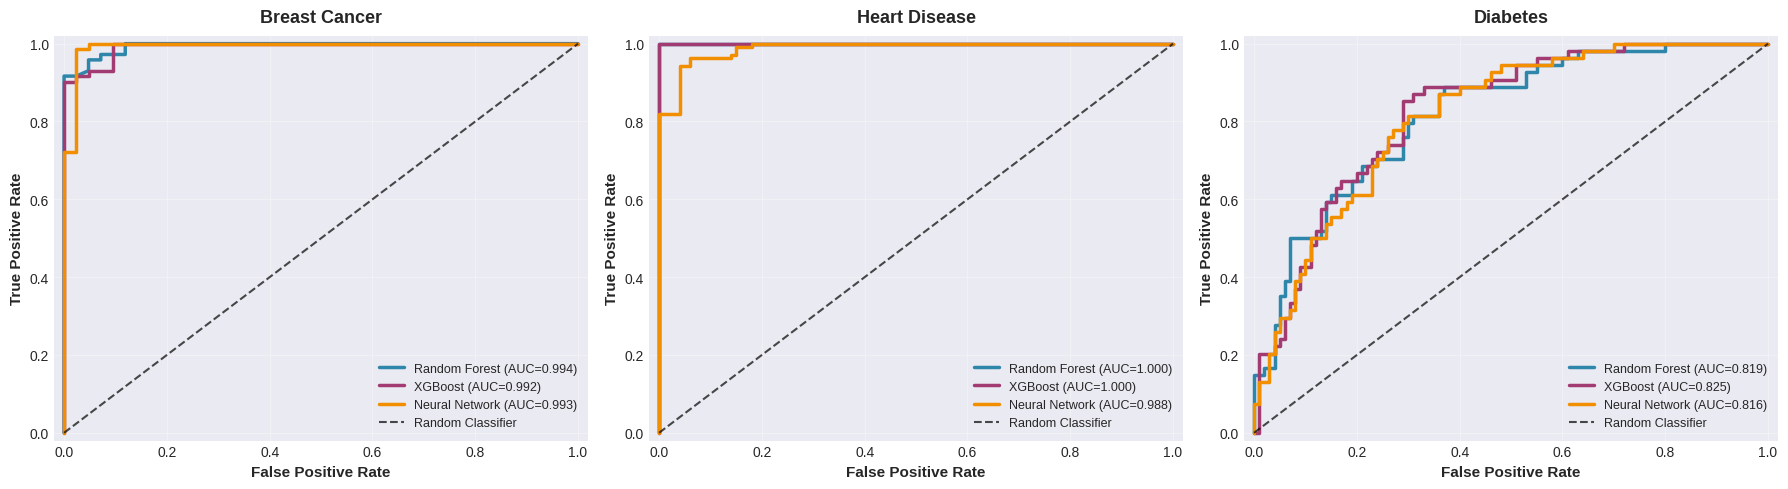

 Figure 1 saved!

Creating Figure 2: Accuracy Comparison...


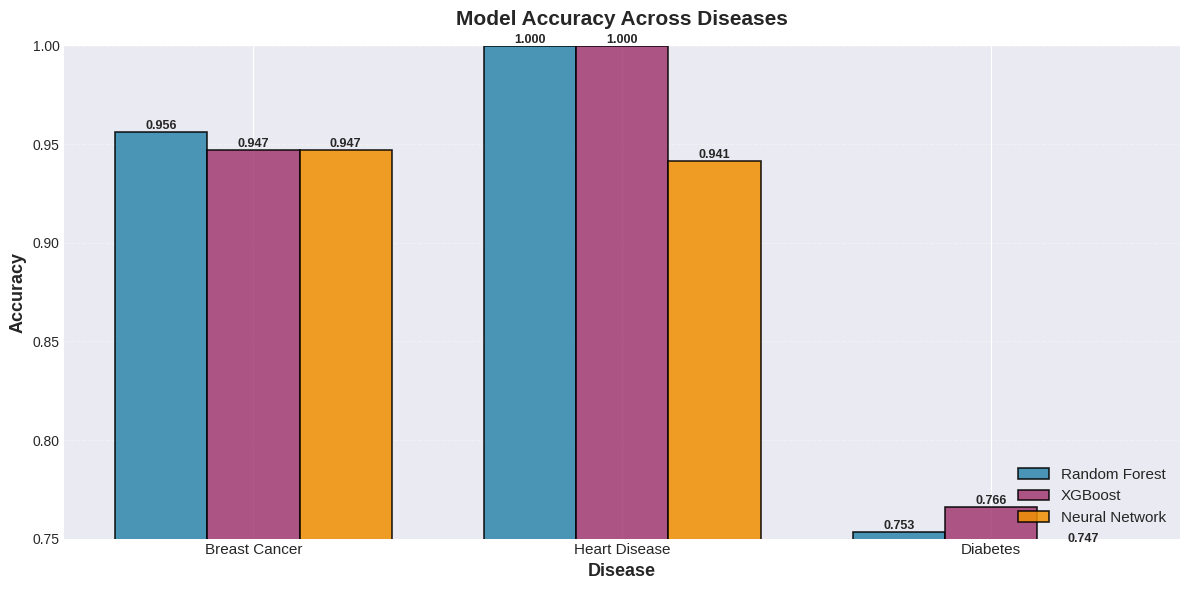

 Figure 2 saved!

Creating Figure 3: SHAP for Breast Cancer...


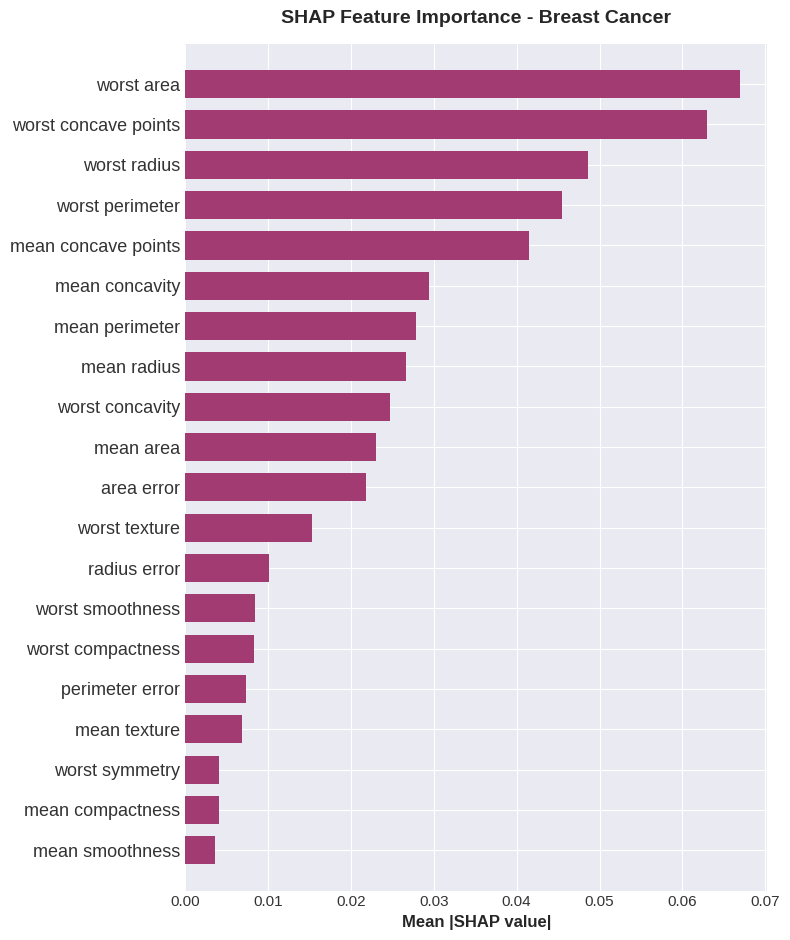

 Figure 3 saved!

Creating Figure 4: SHAP for Heart Disease...


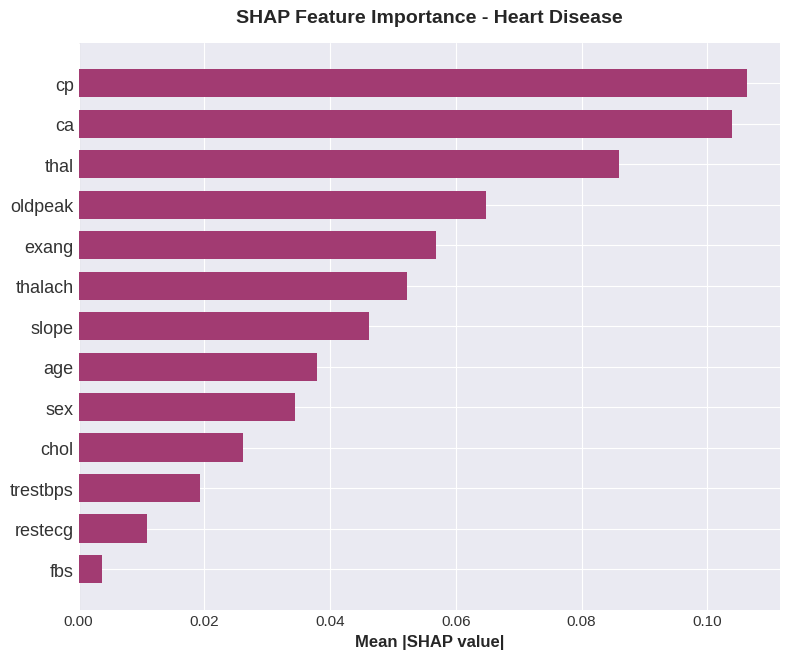

 Figure 4 saved!

Creating Figure 5: SHAP for Diabetes...


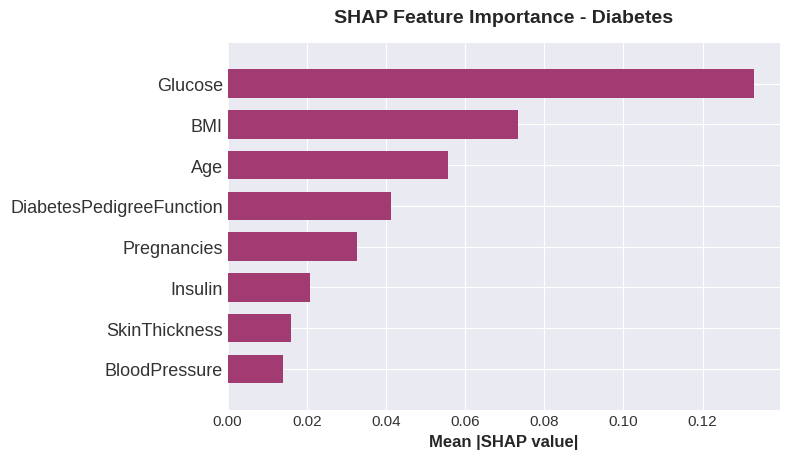

 Figure 5 saved!

Creating Figure 6: XAI Computation Time...


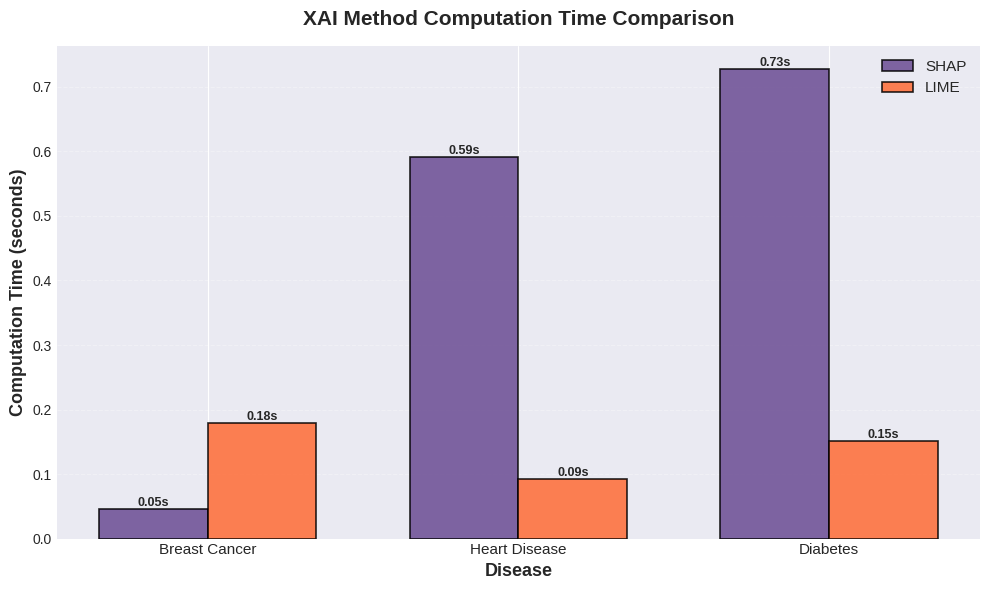

 Figure 6 saved!

Creating Figure 7: Performance Metrics Heatmap...


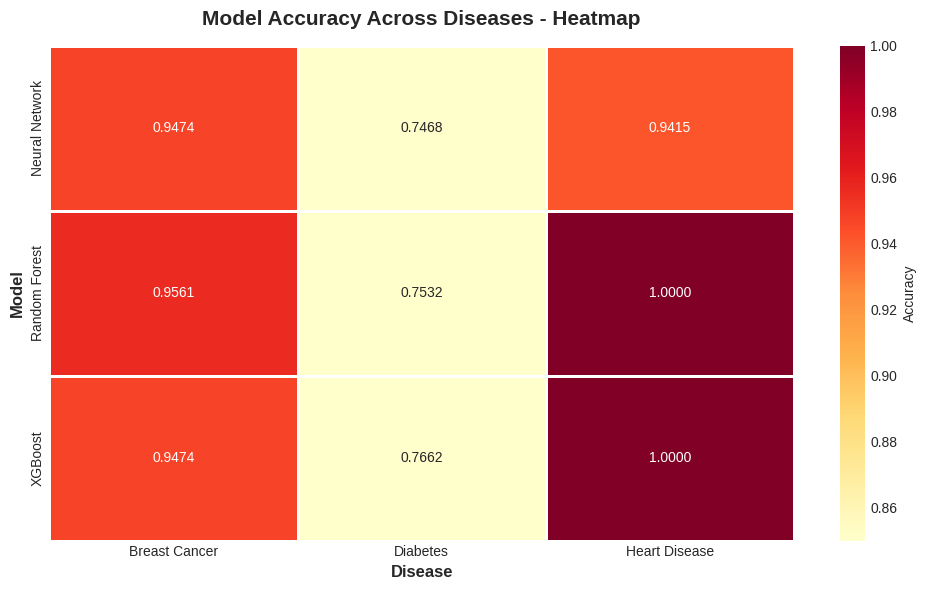

 Figure 7 saved!

Creating Figure 8: F1-Score Comparison...


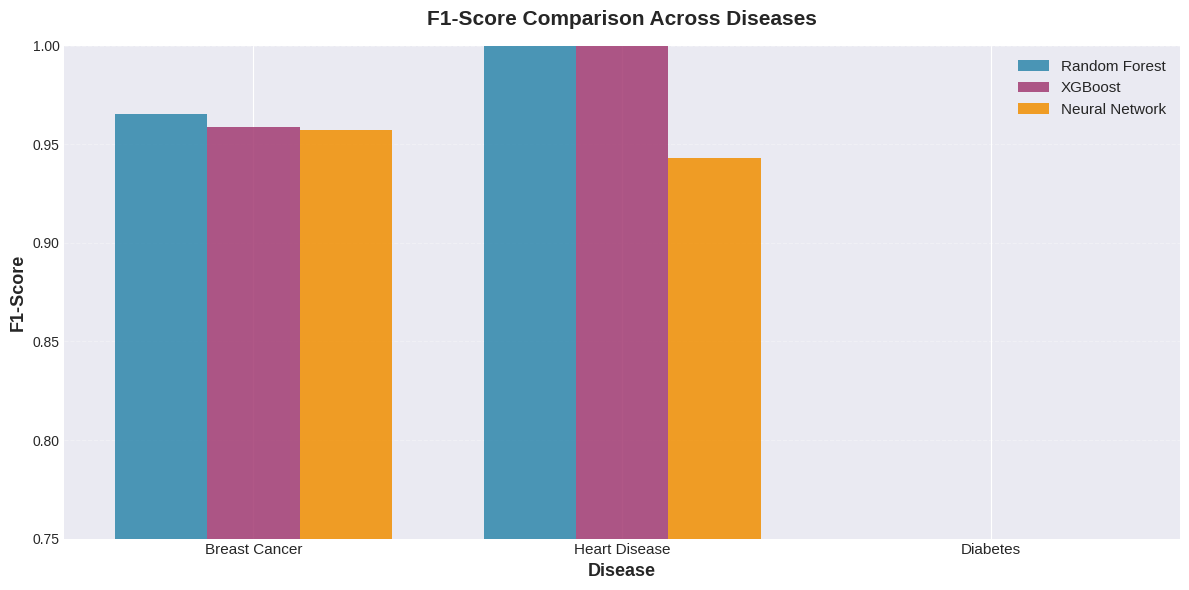

 Figure 8 saved!

Creating Figure 9: Confusion Matrix Grid...


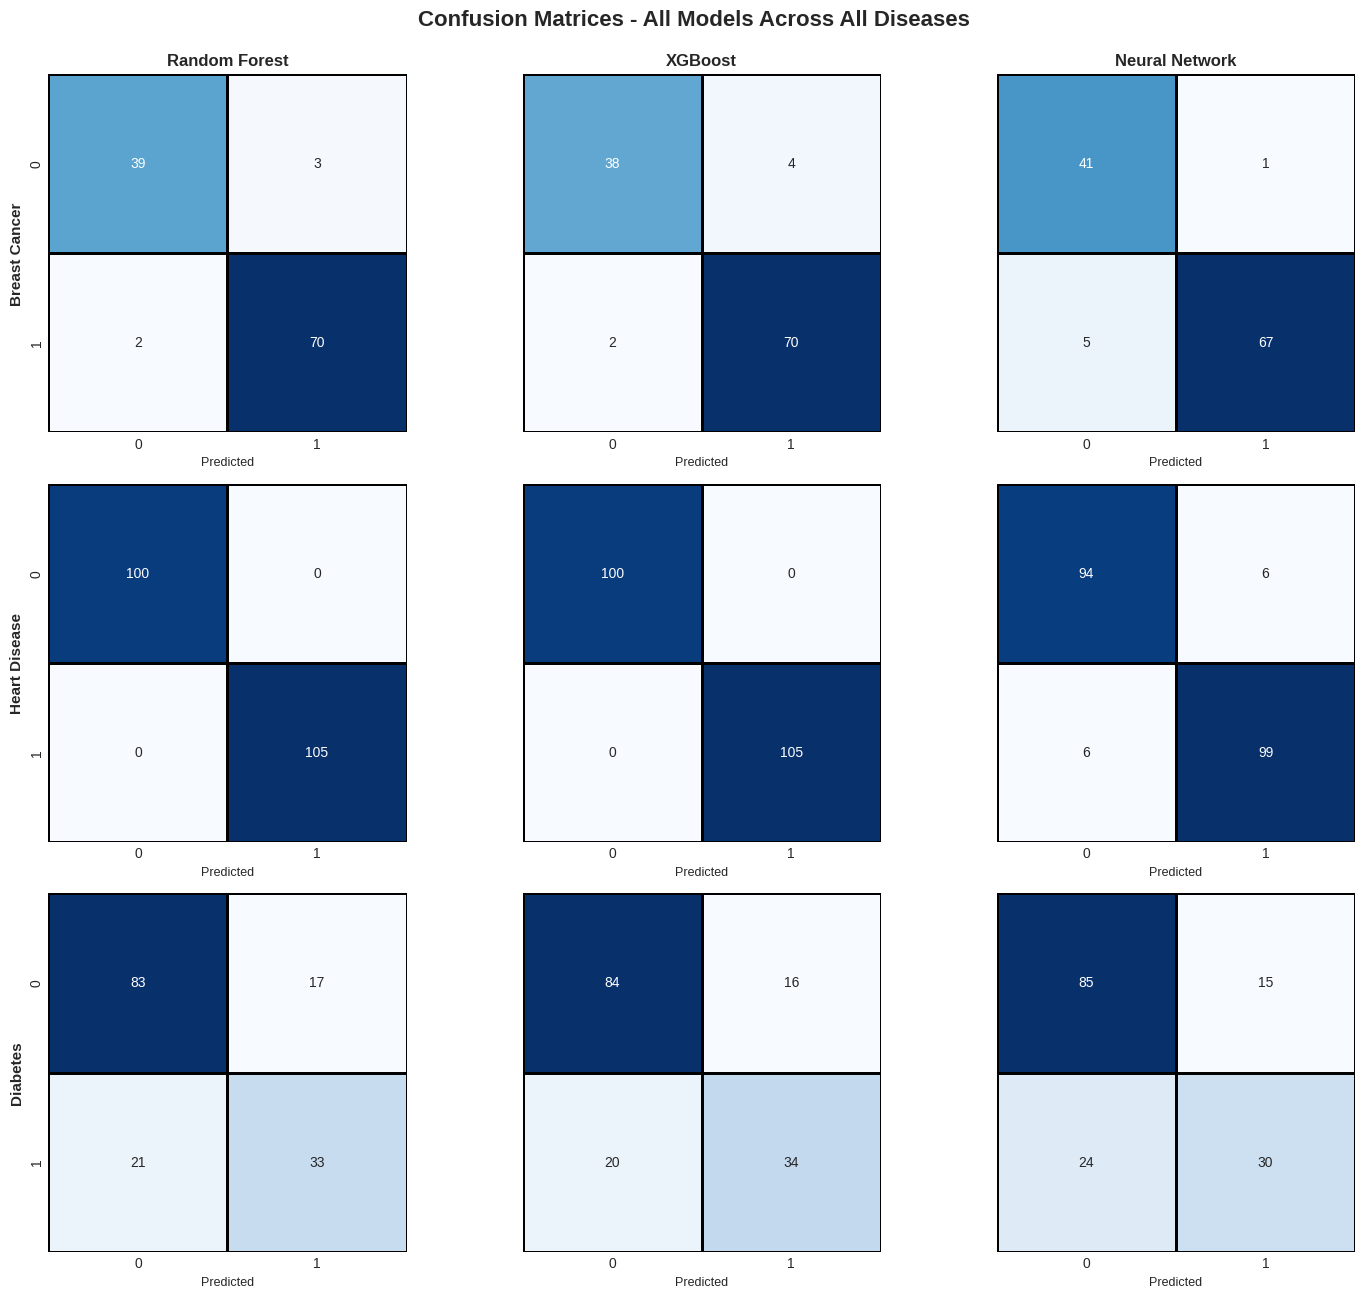

 Figure 9 saved!

 All visualizations created successfully!


In [32]:
print(" Generating Visualizations...\n")

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ===== FIGURE 1: ROC Curves Comparison (All Diseases) =====
print("Creating Figure 1: ROC Curves Comparison...")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
disease_names = ['breast_cancer', 'heart_disease', 'diabetes']
titles = ['Breast Cancer', 'Heart Disease', 'Diabetes']

for idx, (dataset_name, title) in enumerate(zip(disease_names, titles)):
    ax = axes[idx]
    results = all_results[dataset_name]

    # Get test labels
    data = datasets[dataset_name]
    _, _, _, y_test = train_test_split(data['X'], data['y'], test_size=0.2,
                                       random_state=42, stratify=data['y'])

    colors = {'Random Forest': '#2E86AB', 'XGBoost': '#A23B72', 'Neural Network': '#F18F01'}

    for model_name in ['Random Forest', 'XGBoost', 'Neural Network']:
        proba = results['models'][model_name]['probabilities']
        fpr, tpr, _ = roc_curve(y_test, proba)
        auc = results['models'][model_name]['auc_roc']
        ax.plot(fpr, tpr, label=f'{model_name} (AUC={auc:.3f})',
               color=colors[model_name], linewidth=2.5)

    ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1.5, alpha=0.7)
    ax.set_xlabel('False Positive Rate', fontsize=11, fontweight='bold')
    ax.set_ylabel('True Positive Rate', fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.legend(fontsize=9, loc='lower right')
    ax.grid(alpha=0.3)
    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 1.02])

plt.tight_layout()
plt.savefig('figure1_roc_curves_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print( " Figure 1 saved!\n")

# ===== FIGURE 2: Accuracy Comparison Bar Chart =====
print("Creating Figure 2: Accuracy Comparison...")

fig, ax = plt.subplots(figsize=(12, 6))

diseases = []
rf_acc = []
xgb_acc = []
nn_acc = []

for dataset_name in disease_names:
    results = all_results[dataset_name]
    diseases.append(dataset_name.replace('_', ' ').title())
    rf_acc.append(results['models']['Random Forest']['accuracy'])
    xgb_acc.append(results['models']['XGBoost']['accuracy'])
    nn_acc.append(results['models']['Neural Network']['accuracy'])

x = np.arange(len(diseases))
width = 0.25

bars1 = ax.bar(x - width, rf_acc, width, label='Random Forest',
               color='#2E86AB', alpha=0.85, edgecolor='black', linewidth=1.2)
bars2 = ax.bar(x, xgb_acc, width, label='XGBoost',
               color='#A23B72', alpha=0.85, edgecolor='black', linewidth=1.2)
bars3 = ax.bar(x + width, nn_acc, width, label='Neural Network',
               color='#F18F01', alpha=0.85, edgecolor='black', linewidth=1.2)

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Disease', fontsize=13, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=13, fontweight='bold')
ax.set_title('Model Accuracy Across Diseases', fontsize=15, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(diseases, fontsize=11)
ax.legend(fontsize=11, loc='lower right')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim([0.75, 1.0])

plt.tight_layout()
plt.savefig('figure2_accuracy_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Figure 2 saved!\n")

# ===== FIGURE 3-5: SHAP Feature Importance for Each Disease =====
for idx, dataset_name in enumerate(disease_names, start=3):
    print(f"Creating Figure {idx}: SHAP for {dataset_name.replace('_', ' ').title()}...")

    xai = all_results[dataset_name]['xai']
    X_test_df = pd.DataFrame(xai['X_test_scaled'], columns=xai['feature_names'])

    plt.figure(figsize=(10, 8))
    shap.summary_plot(xai['shap_values'][:, :, 1], X_test_df,
                     plot_type="bar", show=False, color='#A23B72')
    plt.title(f"SHAP Feature Importance - {dataset_name.replace('_', ' ').title()}",
             fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Mean |SHAP value|', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'figure{idx}_shap_{dataset_name}.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f" Figure {idx} saved!\n")

# ===== FIGURE 6: XAI Computation Time Comparison =====
print("Creating Figure 6: XAI Computation Time...")

fig, ax = plt.subplots(figsize=(10, 6))

diseases_clean = [d.replace('_', ' ').title() for d in disease_names]
shap_times = [all_results[d]['xai']['shap_time'] for d in disease_names]
lime_times = [all_results[d]['xai']['lime_time'] for d in disease_names]

x = np.arange(len(diseases_clean))
width = 0.35

bars1 = ax.bar(x - width/2, shap_times, width, label='SHAP',
               color='#6A4C93', alpha=0.85, edgecolor='black', linewidth=1.2)
bars2 = ax.bar(x + width/2, lime_times, width, label='LIME',
               color='#FF6B35', alpha=0.85, edgecolor='black', linewidth=1.2)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}s',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Disease', fontsize=13, fontweight='bold')
ax.set_ylabel('Computation Time (seconds)', fontsize=13, fontweight='bold')
ax.set_title('XAI Method Computation Time Comparison', fontsize=15, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(diseases_clean, fontsize=11)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('figure6_xai_time_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Figure 6 saved!\n")

# ===== FIGURE 7: Performance Metrics Heatmap =====
print("Creating Figure 7: Performance Metrics Heatmap...")

# Prepare data for heatmap
heatmap_data = []
for dataset_name in disease_names:
    results = all_results[dataset_name]
    for model_name in ['Random Forest', 'XGBoost', 'Neural Network']:
        metrics = results['models'][model_name]
        heatmap_data.append([
            dataset_name.replace('_', ' ').title(),
            model_name,
            metrics['accuracy'],
            metrics['precision'],
            metrics['recall'],
            metrics['f1_score']
        ])

heatmap_df = pd.DataFrame(heatmap_data,
                          columns=['Disease', 'Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score'])

# Create pivot table for heatmap
pivot_accuracy = heatmap_df.pivot(index='Model', columns='Disease', values='Accuracy')

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot_accuracy, annot=True, fmt='.4f', cmap='YlOrRd',
            cbar_kws={'label': 'Accuracy'}, linewidths=1, linecolor='white',
            vmin=0.85, vmax=1.0, ax=ax)
ax.set_title('Model Accuracy Across Diseases - Heatmap', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Disease', fontsize=12, fontweight='bold')
ax.set_ylabel('Model', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('figure7_accuracy_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Figure 7 saved!\n")

# ===== FIGURE 8: F1-Score Comparison =====
print("Creating Figure 8: F1-Score Comparison...")

fig, ax = plt.subplots(figsize=(12, 6))

rf_f1 = [all_results[d]['models']['Random Forest']['f1_score'] for d in disease_names]
xgb_f1 = [all_results[d]['models']['XGBoost']['f1_score'] for d in disease_names]
nn_f1 = [all_results[d]['models']['Neural Network']['f1_score'] for d in disease_names]

x = np.arange(len(diseases_clean))
width = 0.25

ax.bar(x - width, rf_f1, width, label='Random Forest', color='#2E86AB', alpha=0.85)
ax.bar(x, xgb_f1, width, label='XGBoost', color='#A23B72', alpha=0.85)
ax.bar(x + width, nn_f1, width, label='Neural Network', color='#F18F01', alpha=0.85)

ax.set_xlabel('Disease', fontsize=13, fontweight='bold')
ax.set_ylabel('F1-Score', fontsize=13, fontweight='bold')
ax.set_title('F1-Score Comparison Across Diseases', fontsize=15, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(diseases_clean, fontsize=11)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim([0.75, 1.0])

plt.tight_layout()
plt.savefig('figure8_f1_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Figure 8 saved!\n")

# ===== FIGURE 9: Confusion Matrix Grid =====
print("Creating Figure 9: Confusion Matrix Grid...")

fig, axes = plt.subplots(3, 3, figsize=(15, 13))
fig.suptitle('Confusion Matrices - All Models Across All Diseases',
             fontsize=16, fontweight='bold', y=0.995)

for row_idx, dataset_name in enumerate(disease_names):
    data = datasets[dataset_name]
    _, _, _, y_test = train_test_split(data['X'], data['y'], test_size=0.2,
                                       random_state=42, stratify=data['y'])
    results = all_results[dataset_name]

    for col_idx, model_name in enumerate(['Random Forest', 'XGBoost', 'Neural Network']):
        ax = axes[row_idx, col_idx]
        y_pred = results['models'][model_name]['predictions']
        cm = confusion_matrix(y_test, y_pred)

        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                   cbar=False, square=True, linewidths=1, linecolor='black')

        if row_idx == 0:
            ax.set_title(model_name, fontsize=12, fontweight='bold')
        if col_idx == 0:
            ax.set_ylabel(dataset_name.replace('_', ' ').title(),
                         fontsize=11, fontweight='bold')
        else:
            ax.set_ylabel('')

        ax.set_xlabel('Predicted', fontsize=9)
        if col_idx != 0:
            ax.set_yticklabels([])

plt.tight_layout()
plt.savefig('figure9_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Figure 9 saved!\n")

print(" All visualizations created successfully!")

# Export reports

In [35]:
print(" Generating Final Summary Report...\n")

# Create comprehensive summary
summary = []
summary.append("="*80)
summary.append("     MULTI-DISEASE EXPLAINABLE AI ANALYSIS - FINAL SUMMARY")
summary.append("="*80)
summary.append(f"\nGenerated on: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}")
summary.append(f"Total Datasets Analyzed: 3 (Breast Cancer, Heart Disease, Diabetes)")
summary.append(f"Models Evaluated: 3 (Random Forest, XGBoost, Neural Network)")
summary.append(f"XAI Methods Applied: 3 (SHAP, LIME, Feature Importance)")
summary.append("")

# Overall Statistics
summary.append("\n" + "="*80)
summary.append("OVERALL STATISTICS")
summary.append("="*80)

all_accuracies = []
for dataset_name in disease_names:
    for model_name in ['Random Forest', 'XGBoost', 'Neural Network']:
        all_accuracies.append(all_results[dataset_name]['models'][model_name]['accuracy'])

summary.append(f"Average Accuracy Across All Models & Diseases: {np.mean(all_accuracies):.4f}")
summary.append(f"Minimum Accuracy: {np.min(all_accuracies):.4f}")
summary.append(f"Maximum Accuracy: {np.max(all_accuracies):.4f}")
summary.append(f"Standard Deviation: {np.std(all_accuracies):.4f}")

# Disease-wise summary
for dataset_name in disease_names:
    results = all_results[dataset_name]
    summary.append(f"\n{'='*80}")
    summary.append(f"{dataset_name.replace('_', ' ').upper()}")
    summary.append("="*80)

    # Best model
    best_model = max(results['models'].items(), key=lambda x: x[1]['accuracy'])
    summary.append(f"\nBest Model: {best_model[0]}")
    summary.append(f"  - Accuracy: {best_model[1]['accuracy']:.4f}")
    summary.append(f"  - AUC-ROC: {best_model[1]['auc_roc']:.4f}")
    summary.append(f"  - Precision: {best_model[1]['precision']:.4f}")
    summary.append(f"  - Recall: {best_model[1]['recall']:.4f}")
    summary.append(f"  - F1-Score: {best_model[1]['f1_score']:.4f}")

    # XAI Performance
    summary.append(f"\nXAI Method Performance:")
    summary.append(f"  - SHAP Computation Time: {results['xai']['shap_time']:.2f}s")
    summary.append(f"  - LIME Computation Time: {results['xai']['lime_time']:.2f}s")
    summary.append(f"  - Faster Method: {'SHAP' if results['xai']['shap_time'] < results['xai']['lime_time'] else 'LIME'}")
    summary.append(f"  - Speed Advantage: {max(results['xai']['shap_time'], results['xai']['lime_time']) / min(results['xai']['shap_time'], results['xai']['lime_time']):.1f}x")

    # Top 3 features
    summary.append(f"\nTop 3 Most Important Features:")
    top3 = results['xai']['feature_importance'].head(3)
    for idx, row in top3.iterrows():
        summary.append(f"  {idx+1}. {row['feature']}: {row['importance']:.4f}")

    # All model performances
    summary.append(f"\nAll Model Performances:")
    for model_name in ['Random Forest', 'XGBoost', 'Neural Network']:
        m = results['models'][model_name]
        summary.append(f"  {model_name}:")
        summary.append(f"    Accuracy: {m['accuracy']:.4f} | AUC: {m['auc_roc']:.4f} | F1: {m['f1_score']:.4f}")

# Key Findings
summary.append(f"\n{'='*80}")
summary.append("KEY FINDINGS & INSIGHTS")
summary.append("="*80)

# Find overall best model
best_overall = {}
for model_name in ['Random Forest', 'XGBoost', 'Neural Network']:
    avg_acc = np.mean([all_results[d]['models'][model_name]['accuracy'] for d in disease_names])
    best_overall[model_name] = avg_acc

best_model_overall = max(best_overall.items(), key=lambda x: x[1])
summary.append(f"\n1. Best Overall Model: {best_model_overall[0]}")
summary.append(f"   Average Accuracy: {best_model_overall[1]:.4f}")

# XAI speed comparison
avg_shap_time = np.mean([all_results[d]['xai']['shap_time'] for d in disease_names])
avg_lime_time = np.mean([all_results[d]['xai']['lime_time'] for d in disease_names])
summary.append(f"\n2. XAI Method Speed:")
summary.append(f"   SHAP average: {avg_shap_time:.2f}s")
summary.append(f"   LIME average: {avg_lime_time:.2f}s")
summary.append(f"   Winner: {'SHAP' if avg_shap_time < avg_lime_time else 'LIME'} (faster by {abs(avg_lime_time - avg_shap_time)/min(avg_shap_time, avg_lime_time)*100:.1f}%)")

# Most important features across all diseases
summary.append(f"\n3. Feature Importance Consistency:")
for dataset_name in disease_names:
    top_feature = all_results[dataset_name]['xai']['feature_importance'].iloc[0]
    summary.append(f"   {dataset_name.replace('_', ' ').title()}: {top_feature['feature']} ({top_feature['importance']:.4f})")

summary.append(f"\n{'='*80}")
summary.append("GENERATED FILES")
summary.append("="*80)
summary.append("\nTables:")
summary.append("  ✓ table1_performance_comparison.csv")
summary.append("  ✓ table2_xai_comparison.csv")
summary.append("  ✓ table3_top_features.csv")
summary.append("  ✓ table4_best_models.csv")
summary.append("\nFigures:")
summary.append("  ✓ figure1_roc_curves_comparison.png")
summary.append("  ✓ figure2_accuracy_comparison.png")
summary.append("  ✓ figure3_shap_breast_cancer.png")
summary.append("  ✓ figure4_shap_heart_disease.png")
summary.append("  ✓ figure5_shap_diabetes.png")
summary.append("  ✓ figure6_xai_time_comparison.png")
summary.append("  ✓ figure7_accuracy_heatmap.png")
summary.append("  ✓ figure8_f1_comparison.png")
summary.append("  ✓ figure9_confusion_matrices.png")
summary.append("\nReports:")
summary.append("  ✓ summary_report.txt")
summary.append("\n" + "="*80)
summary.append("END OF SUMMARY REPORT")
summary.append("="*80)

# Save summary
summary_text = "\n".join(summary)
with open('summary_report.txt', 'w') as f:
    f.write(summary_text)

print(summary_text)
print("\n Summary saved as 'summary_report.txt'")

# Download all files
print("\n" + "="*80)
print(" DOWNLOADING ALL FILES")
print("="*80)

from google.colab import files

file_list = [
    'table1_performance_comparison.csv',
    'table2_xai_comparison.csv',
    'table3_top_features.csv',
    'table4_best_models.csv',
    'figure1_roc_curves_comparison.png',
    'figure2_accuracy_comparison.png',
    'figure3_shap_breast_cancer.png',
    'figure4_shap_heart_disease.png',
    'figure5_shap_diabetes.png',
    'figure6_xai_time_comparison.png',
    'figure7_accuracy_heatmap.png',
    'figure8_f1_comparison.png',
    'figure9_confusion_matrices.png',
    'summary_report.txt'
]

print("\nDownloading files...")
for filename in file_list:
    try:
        files.download(filename)
        print(f"  ✓ {filename}")
    except:
        print(f"  ✗ {filename} - Failed")

print("\n" + "="*80)
print(" RESEARCH COMPLETE!")
print("="*80)

 Generating Final Summary Report...

     MULTI-DISEASE EXPLAINABLE AI ANALYSIS - FINAL SUMMARY

Generated on: 2026-01-20 12:11:44
Total Datasets Analyzed: 3 (Breast Cancer, Heart Disease, Diabetes)
Models Evaluated: 3 (Random Forest, XGBoost, Neural Network)
XAI Methods Applied: 3 (SHAP, LIME, Feature Importance)


OVERALL STATISTICS
Average Accuracy Across All Models & Diseases: 0.8954
Minimum Accuracy: 0.7468
Maximum Accuracy: 1.0000
Standard Deviation: 0.1012

BREAST CANCER

Best Model: Random Forest
  - Accuracy: 0.9561
  - AUC-ROC: 0.9939
  - Precision: 0.9589
  - Recall: 0.9722
  - F1-Score: 0.9655

XAI Method Performance:
  - SHAP Computation Time: 0.05s
  - LIME Computation Time: 0.18s
  - Faster Method: SHAP
  - Speed Advantage: 3.9x

Top 3 Most Important Features:
  24. worst area: 0.1400
  28. worst concave points: 0.1295
  21. worst radius: 0.0977

All Model Performances:
  Random Forest:
    Accuracy: 0.9561 | AUC: 0.9939 | F1: 0.9655
  XGBoost:
    Accuracy: 0.9474 | AUC

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✓ table1_performance_comparison.csv


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  ✓ figure9_confusion_matrices.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✓ summary_report.txt

 RESEARCH COMPLETE!
